# Warm vs. Cool Color Classifier: How Many Hidden Neurons Do You Need?

**Lesson goal:** You already know that a simple rule like `R > B` can't perfectly
separate "warm" colors (red/orange/yellow) from "cool" colors (green/cyan/blue/violet),
because the true definition of warm/cool comes from a pixel's **hue**, which wraps
around a circle. That wraparound shape can't be split by a single straight line
no matter how you draw it.

A small neural network *can* learn this boundary -- but how small can it be?
In this notebook, you'll build the network yourself, then **change one number**
(the size of the hidden layer) and watch what happens to accuracy.

Run each cell in order. Cells you're meant to experiment with are marked
**🔽 EDIT ME**.

## 1. Build the dataset

We label each pixel "warm" or "cool" using its true HSV hue, not a hand-written rule.

We're splitting this into **three** sets, not two:
- **Train** -- the network's weights are fit to this data
- **Validation** -- you'll check accuracy against this *repeatedly* while experimenting
  with `N_HIDDEN` below. It's fine to look at this as many times as you want.
- **Test** -- completely untouched until the very last cell in this notebook. You'll
  use it exactly once, after you've already decided on your final N_HIDDEN.

In [9]:
import numpy as np
import colorsys
import matplotlib.pyplot as plt

np.random.seed(0)

# Warm = red -> orange -> yellow (hue near 0 degrees), wrapping around
# through the top of the circle. Cool = everything else.
WARM_HUE_LOW = 1/6 + 0.001   # just past pure yellow's hue, so yellow -> warm
WARM_HUE_HIGH = 0.92         # red-violet boundary on the other side

def hue_label(r, g, b):
    """Return 1 (warm) or 0 (cool), or None for near-gray pixels.
    h stands for hue - where the color sits on the color weel (0 -1 aka 0-360)
    s stands for saturation - how colorful vs gray the pixel is (0 = gray, 1 = fully vivid color)
    v stannds for value - how bring the color is (0 = black, 1 = full bright)"""
    h, s, v = colorsys.rgb_to_hsv(r / 255, g / 255, b / 255)
    if s < 0.15:
        return None  # too little color to call warm or cool - mostly a gray tone
    if h <= WARM_HUE_LOW or h>= WARM_HUE_HIGH:
        return 1
    else:
        return 0



def build_dataset(n_samples, seed):
    #creates a random generator using a seeded (aka reproducable) value
    rng = np.random.default_rng(seed)
    #creates a n_samples number of integers with values at 0 going to 255 to be a pixel (RGB values)
    rgb = rng.integers(0, 256, size=(n_samples, 3))
    #makes two lists for features and lables
    X_list, y_list = [], []
    #goes through every pixel that was generated
    for r, g, b in rgb:
        #creates a label for each pixel
        label = hue_label(r, g, b)
        #as long as that pixel is not grey
        if label is not None:
            #Add the pixel to the features
            X_list.append([r, g, b])
            #Add the result to the labels.
            y_list.append(label)
    #Converts the numpy array of pixels to be on a 0-1 scale
    x = np.array(X_list, dtype=float) / 255.0
    #Makes it so the y_list has a second value. Code breaks without this y goes from (1, ) to (1, 1)
    y = np.array(y_list, dtype=float).reshape(-1, 1)
    return x, y


# Three-way split: most of the data goes to training, with separate
# validation and test sets. (Ratios matter less here than usual because
# we can generate as much labeled data as we want for free -- but the
# three-way split itself is still the right habit to build, since most
# real datasets DON'T have that luxury.)
X_train, y_train = build_dataset(8000, seed=0)
X_val, y_val = build_dataset(2000, seed=50)     # checked repeatedly while experimenting
X_test, y_test = build_dataset(2000, seed=99)   # touched exactly once, at the very end

print(f"Training set:   {len(y_train)} pixels  ({int(y_train.sum())} warm / {int(len(y_train)-y_train.sum())} cool)")
print(f"Validation set: {len(y_val)} pixels  ({int(y_val.sum())} warm / {int(len(y_val)-y_val.sum())} cool)")
print(f"Test set:       {len(y_test)} pixels  ({int(y_test.sum())} warm / {int(len(y_test)-y_test.sum())} cool)  <- don't peek yet!")

Training set:   7831 pixels  (1964 warm / 5867 cool)
Validation set: 1951 pixels  (478 warm / 1473 cool)
Test set:       1957 pixels  (516 warm / 1441 cool)  <- don't peek yet!


## 2. See why this can't be solved with a straight line

Plot every pixel's Red and Blue value, colored by its *true* warm/cool label.
If warm and cool formed two clean, separate blobs, a single straight line
could divide them. Look closely at where the colors overlap.

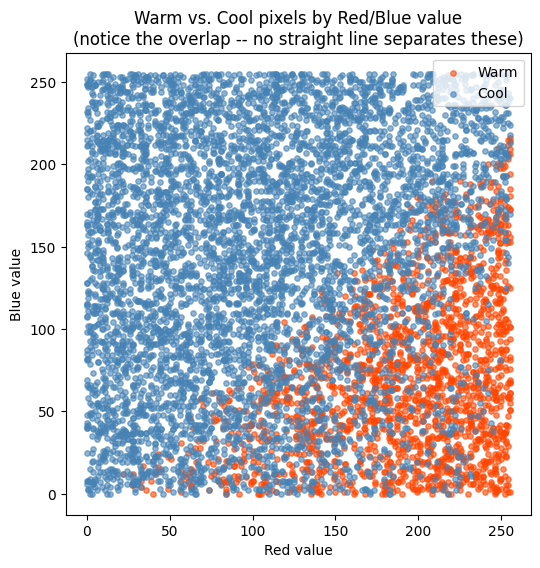

In [ ]:
#Creates the plot
plt.figure(figsize=(6, 6))
#Pulls all index values data from the training set that is considered warm
warm_mask = y_train[:, 0] == 1
#plots all index values where it is warm
plt.scatter(X_train[warm_mask, 0]*255, X_train[warm_mask, 2]*255,
            c='orangered', label='Warm', alpha=0.6, s=15)
#plots inverse index values
plt.scatter(X_train[~warm_mask, 0]*255, X_train[~warm_mask, 2]*255,
            c='steelblue', label='Cool', alpha=0.6, s=15)
plt.xlabel('Red value')
plt.ylabel('Blue value')
plt.title('Warm vs. Cool pixels by Red/Blue value\n(notice the overlap -- no straight line separates these)')
plt.legend()
plt.show()

**Question:** Find a point where an orange dot and a blue dot sit almost on top of
each other. What's different about those two pixels that you *can't* see on this
2D plot? (Hint: there's a third color channel involved.)

## 3. The network

A small 2-layer network: 3 inputs (R, G, B) &rarr; hidden layer (ReLU) &rarr; 1 output (sigmoid, warm probability).

### 🔽 EDIT ME
Change `N_HIDDEN` below to any number from 1 to 64 and re-run **this cell and everything below it** to see what happens.

In [25]:
N_HIDDEN = 5 # <-- CHANGE THIS NUMBER AND RE-RUN THE CELLS BELOW

In [26]:
#Sets up ReLU activation function
def relu(z):
    return np.maximum(0, z)

#Sets up Sigmoid activation function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

#Randomly generates the starting values for all weights and biases in the neural network
#The parameters are # of inputs, # of hidden nodes, # of outputs, and seed
def init_params(n_in, n_hidden, n_out, seed=42):
    #Creates the randomizer using the seed value
    rng = np.random.default_rng(seed)
    #Creates the weights from the input to the hidden layer.
    #normal(0, 1) is using a standard normal distribution (a specific bell-curve/Gaussian shape, mean 0, std 1).
    #np.sqrt(2/n_in) scales the value to keep them from starting a very large or very small value. 
    W1 = rng.normal(0, 1, (n_in, n_hidden)) * np.sqrt(2 / n_in)   # He init, good for ReLU
    #Starating bias for all neurons in hidden layer 1 at zero
    b1 = np.zeros((1, n_hidden))
    #Create the weights in the hidden layer to the output layer.
    W2 = rng.normal(0, 1, (n_hidden, n_out)) * np.sqrt(1 / n_hidden)
    #creates the bias for the output layer at zero
    b2 = np.zeros((1, n_out))
    return W1, b1, W2, b2

def forward(X, W1, b1, W2, b2):
    #The @ sign does the dot product between the three weights and the three inputs
    Z1 = X @ W1 + b1
    A1 = relu(Z1)
    Z2 = A1 @ W2 + b2
    A2 = sigmoid(Z2)
    return Z1, A1, Z2, A2

def bce_loss(A2, y, eps=1e-9):
    return -np.mean(y * np.log(A2 + eps) + (1 - y) * np.log(1 - A2 + eps))

def backward(X, y, Z1, A1, A2, W2):
    #Gets the number of samples
    n = X.shape[0]
    #Error(predicted - actual)
    #A2 and y are both numpy arrays. We want an average value for all inputs for the error. To get that, we divide each error by the total number of elements and store that as a numpy array.
    dZ2 = (A2 - y) / n
    #Dot product between error and input to the sigmoid neron (averaged by using the number of samples)
    #This is still an array there is one value per line in the neural network
    dW2 = A1.T @ dZ2
    #Only one bias for the sigmoid neuron, so add up all the error values - makes an average because we divided by the number of samples already.
    db2 = dZ2.sum(axis=0, keepdims=True)
    #Error times old weight 2 values. We will use this to help in the input to h1 layer
    dA1 = dZ2 @ W2.T
    #Determining whether or not to multiply by the 1 or 0 for RelU
    dZ1 = dA1 * (Z1 > 0)     # ReLU derivative: 1 where Z1>0, else 0
    #Detemrining what to update the weights by, the same as before
    dW1 = X.T @ dZ1
    #Determing what to update the bias by, same as before, but using Z1 instead of Z2.
    db1 = dZ1.sum(axis=0, keepdims=True)
    return dW1, db1, dW2, db2

In [27]:
def train(X, y, n_hidden, lr=0.5, epochs=3000, seed=42, track_history=False):
    n_in, n_out = X.shape[1], y.shape[1]
    W1, b1, W2, b2 = init_params(n_in, n_hidden, n_out, seed=seed)
    history = []
    for epoch in range(epochs):
        #Complete one forward pass
        Z1, A1, Z2, A2 = forward(X, W1, b1, W2, b2)
        #Complete one backward pass
        dW1, db1, dW2, db2 = backward(X, y, Z1, A1, A2, W2)
        #update the weights and biases
        W2 -= lr * dW2; b2 -= lr * db2
        W1 -= lr * dW1; b1 -= lr * db1
        #pay attention to the loss at every 50 epochs, add it to a list calle dhistory.
        if track_history and epoch % 50 == 0:
            loss = bce_loss(A2, y)
            acc = ((A2 > 0.5).astype(float) == y).mean()
            history.append((epoch, loss, acc))
    return W1, b1, W2, b2, history

W1, b1, W2, b2, history = train(X_train, y_train, N_HIDDEN, track_history=True)
print(f"Trained a 3 -> {N_HIDDEN} -> 1 network.")

Trained a 3 -> 5 -> 1 network.


## 4. Evaluate on the validation set

This is data the network never trained on -- but since we're about to go tune
`N_HIDDEN` based on what we see here, this is VALIDATION data, not test data.

N_HIDDEN = 5
  Validation accuracy: 0.999
  Warm recall:   0.998   (of truly-warm pixels, % correctly caught)
  Cool recall:   1.000   (of truly-cool pixels, % correctly caught)


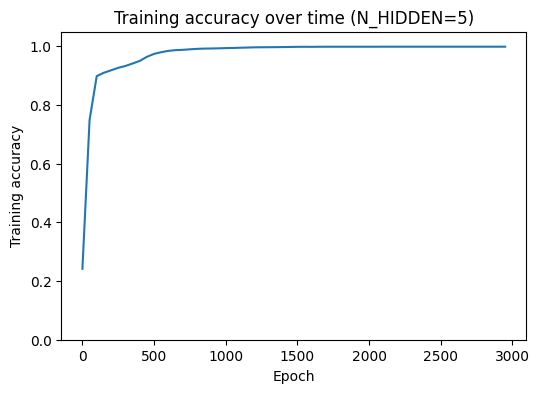

In [28]:
def evaluate(X, y, W1, b1, W2, b2):
    _, _, _, A2 = forward(X, W1, b1, W2, b2)
    preds = (A2 > 0.5).astype(float)
    acc = (preds == y).mean()
    warm_mask = y[:, 0] == 1
    warm_recall = (preds[warm_mask] == 1).mean() if warm_mask.sum() > 0 else float('nan')
    cool_recall = (preds[~warm_mask] == 0).mean() if (~warm_mask).sum() > 0 else float('nan')
    return acc, warm_recall, cool_recall

val_acc, warm_recall, cool_recall = evaluate(X_val, y_val, W1, b1, W2, b2)
print(f"N_HIDDEN = {N_HIDDEN}")
print(f"  Validation accuracy: {val_acc:.3f}")
print(f"  Warm recall:   {warm_recall:.3f}   (of truly-warm pixels, % correctly caught)")
print(f"  Cool recall:   {cool_recall:.3f}   (of truly-cool pixels, % correctly caught)")

epochs_seen, losses, accs = zip(*history)
plt.figure(figsize=(6,4))
plt.plot(epochs_seen, accs)
plt.xlabel('Epoch')
plt.ylabel('Training accuracy')
plt.title(f'Training accuracy over time (N_HIDDEN={N_HIDDEN})')
plt.ylim(0, 1.05)
plt.show()

## 4b. Confusion matrix

The `warm_recall` and `cool_recall` numbers above are useful, but a confusion
matrix shows the same information laid out as actual counts, so you can see
exactly which mistakes the network makes:

- **True negatives** (top-left): cool pixels correctly called cool
- **False positives** (top-right): cool pixels wrongly called warm
- **False negatives** (bottom-left): warm pixels wrongly called cool
- **True positives** (bottom-right): warm pixels correctly called warm

This is especially useful for comparing strategies later (e.g. oversampling)
-- accuracy alone can hide a network that's great at one class and bad at the
other, but the confusion matrix makes that trade-off visible immediately.

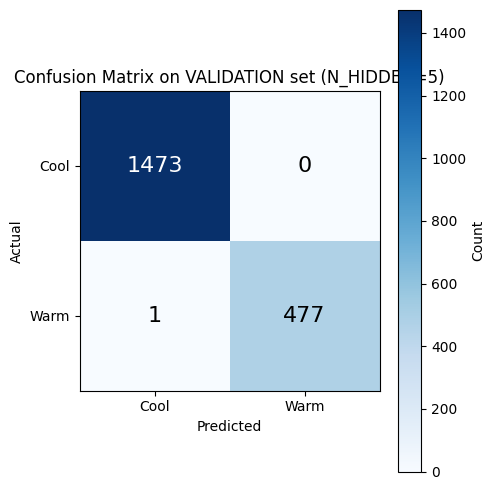

True negatives  (cool -> cool):  1473
False positives (cool -> warm):  0
False negatives (warm -> cool):  1
True positives  (warm -> warm):  477


In [29]:
def confusion_matrix(y_true, y_pred):
    y_true = y_true[:, 0]
    y_pred = y_pred[:, 0]
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    tp = np.sum((y_true == 1) & (y_pred == 1))
    return np.array([[tn, fp], [fn, tp]])  # rows = actual, cols = predicted


_, _, _, A2_val = forward(X_val, W1, b1, W2, b2)
y_pred_val = (A2_val > 0.5).astype(float)
cm = confusion_matrix(y_val, y_pred_val)

labels = ['Cool', 'Warm']
fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_xticklabels(labels)
ax.set_yticks([0, 1]); ax.set_yticklabels(labels)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix on VALIDATION set (N_HIDDEN={N_HIDDEN})')

for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=16)

plt.colorbar(im, label='Count')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
print(f"True negatives  (cool -> cool):  {tn}")
print(f"False positives (cool -> warm):  {fp}")
print(f"False negatives (warm -> cool):  {fn}")
print(f"True positives  (warm -> warm):  {tp}")

## 5. See the decision boundary the network actually learned

This is the most direct way to *see* what more or fewer hidden neurons buys you.
We fix Green at a middle value and color every possible (Red, Blue) combination
by what the network predicts. Compare this to the scatter plot in step 2 --
does the boundary shape make sense given where the warm/cool points actually sat?

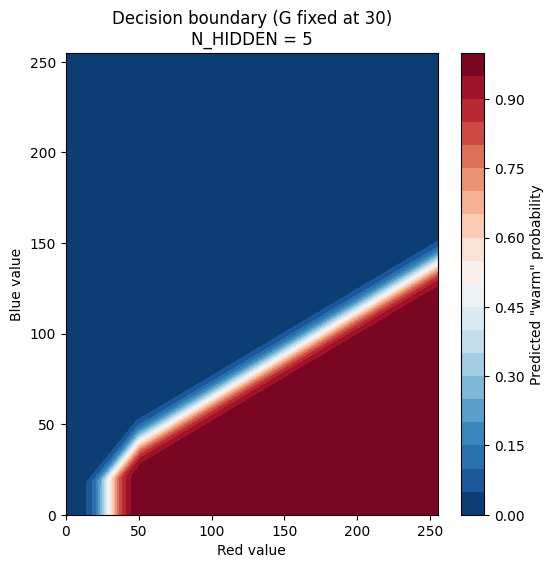

In [30]:
def plot_decision_boundary(W1, b1, W2, b2, g_fixed=128, n_hidden=None, ax=None):
    r_vals = np.linspace(0, 255, 150)
    b_vals = np.linspace(0, 255, 150)
    R, B = np.meshgrid(r_vals, b_vals)
    G = np.full_like(R, g_fixed)
    grid = np.stack([R.ravel(), G.ravel(), B.ravel()], axis=1) / 255.0
    _, _, _, preds = forward(grid, W1, b1, W2, b2)
    preds = preds.reshape(R.shape)

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))
    cs = ax.contourf(R, B, preds, levels=np.linspace(0, 1, 21), cmap='RdBu_r', vmin=0, vmax=1)
    ax.set_xlabel('Red value')
    ax.set_ylabel('Blue value')
    title = f'Decision boundary (G fixed at {g_fixed})'
    if n_hidden is not None:
        title += f'\nN_HIDDEN = {n_hidden}'
    ax.set_title(title)
    return cs

fig, ax = plt.subplots(figsize=(6, 6))
cs = plot_decision_boundary(W1, b1, W2, b2, g_fixed=30, n_hidden=N_HIDDEN, ax=ax)
plt.colorbar(cs, label='Predicted "warm" probability')
plt.show()

## 6. (Optional extension) Automatically compare many hidden-layer sizes

Instead of manually changing `N_HIDDEN` and re-running, this cell trains a fresh
network at each size in the list and plots the results automatically. This takes
a minute or two to run. Still using the **validation** set here, since we're
comparing/selecting a hyperparameter.

N_HIDDEN=  1   avg val acc=0.844   (range: 0.755-0.889)


N_HIDDEN=  2   avg val acc=0.888   (range: 0.888-0.889)


N_HIDDEN=  3   avg val acc=0.925   (range: 0.888-0.998)


N_HIDDEN=  4   avg val acc=0.997   (range: 0.995-0.998)


N_HIDDEN=  6   avg val acc=0.962   (range: 0.888-0.998)


N_HIDDEN=  8   avg val acc=0.999   (range: 0.998-1.000)


N_HIDDEN= 16   avg val acc=0.999   (range: 0.998-0.999)


N_HIDDEN= 32   avg val acc=0.999   (range: 0.999-0.999)


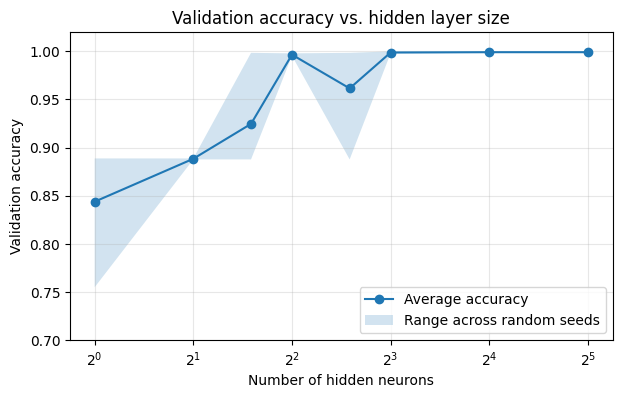

In [9]:
hidden_sizes_to_test = [1, 2, 3, 4, 6, 8, 16, 32]
results = []

for n_hidden in hidden_sizes_to_test:
    accs = []
    for seed in [1, 2, 3]:   # average over a few random starting points
        W1_t, b1_t, W2_t, b2_t, _ = train(X_train, y_train, n_hidden, seed=seed)
        acc, _, _ = evaluate(X_val, y_val, W1_t, b1_t, W2_t, b2_t)
        accs.append(acc)
    results.append((n_hidden, np.mean(accs), np.min(accs), np.max(accs)))
    print(f"N_HIDDEN={n_hidden:3d}   avg val acc={np.mean(accs):.3f}   (range: {np.min(accs):.3f}-{np.max(accs):.3f})")

sizes, avg_accs, min_accs, max_accs = zip(*results)
plt.figure(figsize=(7, 4))
plt.plot(sizes, avg_accs, marker='o', label='Average accuracy')
plt.fill_between(sizes, min_accs, max_accs, alpha=0.2, label='Range across random seeds')
plt.xlabel('Number of hidden neurons')
plt.ylabel('Validation accuracy')
plt.title('Validation accuracy vs. hidden layer size')
plt.xscale('log', base=2)
plt.ylim(0.7, 1.02)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Reflection questions:**
1. At what hidden-layer size does accuracy stop improving?
2. Some sizes show a wide "range across random seeds" -- what does that tell you about
   what's happening during training at that size?
3. Why doesn't accuracy keep climbing forever as you add more neurons?

## 7. Final evaluation -- the real test set

Everything above used the **validation** set, which you were free to check as many
times as you wanted while experimenting with `N_HIDDEN`. The **test** set has been
sitting untouched this whole notebook.

This next cell is the only place in the entire notebook allowed to use it, and
it should only be run **once**, after you've already settled on your final
`N_HIDDEN` choice from the experimentation above.

⚠️ If you look at this result and then go back and change `N_HIDDEN` to try to
improve it, you've broken the entire point of having a test set -- you'd be
tuning on it, exactly like we were (without realizing it) before we added the
validation set.

FINAL, one-time TEST SET evaluation (N_HIDDEN=8):
  Test accuracy: 0.998
  Warm recall:   0.998
  Cool recall:   0.999


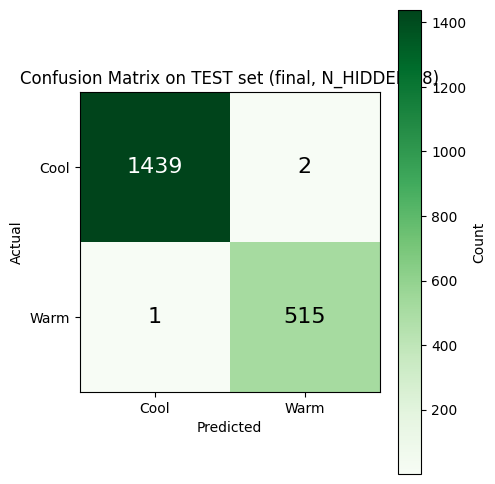

In [10]:
FINAL_N_HIDDEN = N_HIDDEN  # whatever you last settled on above

W1_final, b1_final, W2_final, b2_final, _ = train(X_train, y_train, FINAL_N_HIDDEN)
final_acc, final_warm_recall, final_cool_recall = evaluate(
    X_test, y_test, W1_final, b1_final, W2_final, b2_final
)

print(f"FINAL, one-time TEST SET evaluation (N_HIDDEN={FINAL_N_HIDDEN}):")
print(f"  Test accuracy: {final_acc:.3f}")
print(f"  Warm recall:   {final_warm_recall:.3f}")
print(f"  Cool recall:   {final_cool_recall:.3f}")

_, _, _, A2_test_final = forward(X_test, W1_final, b1_final, W2_final, b2_final)
y_pred_test_final = (A2_test_final > 0.5).astype(float)
cm_final = confusion_matrix(y_test, y_pred_test_final)

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(cm_final, cmap='Greens')
ax.set_xticks([0, 1]); ax.set_xticklabels(['Cool', 'Warm'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['Cool', 'Warm'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix on TEST set (final, N_HIDDEN={FINAL_N_HIDDEN})')
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm_final[i, j]), ha='center', va='center',
                color='white' if cm_final[i, j] > cm_final.max() / 2 else 'black', fontsize=16)
plt.colorbar(im, label='Count')
plt.tight_layout()
plt.show()

**Reflection question:** Is your final test accuracy close to the validation
accuracy you saw during experimentation? It should be -- if it's noticeably
*worse*, that's a sign the validation set was accidentally being "overfit to"
during tuning (more of a concern with harder problems and more hyperparameters
than we have here, but the habit matters regardless of problem size).